# Project 1: Quantum ML Classifier
## MNIST Binary Classification — Digit 0 vs Digit 1

### Methods Compared:
1. Classical SVM (RBF kernel) — baseline
2. QSVM (ZZFeatureMap) — quantum kernel
3. VQC (RealAmplitudes) — fully quantum model

### Dataset:
- Source: sklearn digits (MNIST subset)
- Binary: digit 0 vs digit 1
- Samples: 200
- Features: PCA reduced to 2 dimensions
- Normalized: [0, 1]

In [1]:
# Cell 2 - imports
import sys
sys.path.append('../src')

import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import display, Image
import time

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split

import qiskit
import qiskit_machine_learning
print(f"qiskit            : {qiskit.__version__}")
print(f"qiskit-ml         : {qiskit_machine_learning.__version__}")

from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
from qiskit_machine_learning.kernels import FidelityStatevectorKernel
from qiskit_machine_learning.algorithms.classifiers import VQC
from qiskit_algorithms.optimizers import COBYLA
from qml_utils import load_mnist_binary

import os
os.makedirs("../results", exist_ok=True)

print("all imports done!")

qiskit            : 0.45.3
qiskit-ml         : 0.7.2
all imports done!


## Step 1: Load MNIST Binary Dataset

Loading digit 0 vs digit 1 from sklearn digits.
200 samples, PCA reduced to 2 features.
Normalized to [0, 1] for quantum encoding.

In [2]:
# Cell 4 - load MNIST binary dataset
X, y = load_mnist_binary(
    n_samples=200,
    n_features=2,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

print("MNIST binary dataset loaded!")
print(f"total samples  : {len(X)}")
print(f"train samples  : {len(X_train)}")
print(f"test samples   : {len(X_test)}")
print(f"features       : {X.shape[1]}")
print(f"classes        : {np.unique(y)}")
print(f"feature range  : [{X.min():.2f}, {X.max():.2f}]")
print(f"class balance  : 0={sum(y==0)}, 1={sum(y==1)}")

MNIST binary dataset loaded!
total samples  : 200
train samples  : 140
test samples   : 60
features       : 2
classes        : [0 1]
feature range  : [0.00, 1.00]
class balance  : 0=98, 1=102


## Step 2: Classical SVM Baseline

Train classical SVM with RBF kernel.
This is our benchmark to beat!
Record training time for comparison.

In [3]:
# classical SVM baseline
start = time.time()

classical_svm = SVC(kernel='rbf', random_state=42)
classical_svm.fit(X_train, y_train)

classical_time = time.time() - start
y_pred_classical = classical_svm.predict(X_test)
classical_accuracy = accuracy_score(
    y_test, y_pred_classical
)
cm_classical = confusion_matrix(
    y_test, y_pred_classical
)

print("classical SVM results:")
print(f"accuracy   : {classical_accuracy*100:.2f}%")
print(f"correct    : {int(classical_accuracy*len(X_test))}/{len(X_test)}")
print(f"train time : {classical_time:.3f}s")
print(f"\nconfusion matrix:")
print(cm_classical)

classical SVM results:
accuracy   : 100.00%
correct    : 60/60
train time : 0.013s

confusion matrix:
[[33  0]
 [ 0 27]]


## Step 3: QSVM with ZZFeatureMap

Replace classical RBF kernel with quantum kernel.
ZZFeatureMap encodes data into quantum Hilbert space.
FidelityStatevectorKernel computes quantum similarity.

In [5]:
num_features = 2

feature_map = ZZFeatureMap(
    feature_dimension=num_features,
    reps=2
)

quantum_kernel = FidelityStatevectorKernel(
    feature_map=feature_map
)

print("training QSVM on MNIST...")
start = time.time()

qsvm = SVC(kernel=quantum_kernel.evaluate)
qsvm.fit(X_train, y_train)

qsvm_time = time.time() - start
y_pred_qsvm = qsvm.predict(X_test)
qsvm_accuracy = accuracy_score(
    y_test, y_pred_qsvm
)
cm_qsvm = confusion_matrix(
    y_test, y_pred_qsvm
)

print("QSVM results:")
print(f"accuracy   : {qsvm_accuracy*100:.2f}%")
print(f"correct    : {int(qsvm_accuracy*len(X_test))}/{len(X_test)}")
print(f"train time : {qsvm_time:.3f}s")
print(f"\nconfusion matrix:")
print(cm_qsvm)


training QSVM on MNIST...
QSVM results:
accuracy   : 100.00%
correct    : 60/60
train time : 2.585s

confusion matrix:
[[33  0]
 [ 0 27]]


## Step 4: VQC — Variational Quantum Classifier

Fully quantum end-to-end classifier.
RealAmplitudes ansatz with 8 trainable parameters.
COBYLA optimizer — same as VQE and QAOA!

In [6]:
# Cell 10 - VQC on MNIST
ansatz = RealAmplitudes(
    num_qubits=num_features,
    reps=3
)

loss_history = []

def callback(weights, obj_func_eval):
    loss_history.append(obj_func_eval)
    if len(loss_history) % 20 == 0:
        print(f"  iteration {len(loss_history)}"
              f" → loss = {obj_func_eval:.4f}")

print("training VQC on MNIST...")
print("this will take 3-5 minutes...")
start = time.time()

vqc = VQC(
    feature_map=feature_map,
    ansatz=ansatz,
    optimizer=COBYLA(maxiter=150),
    callback=callback
)

vqc.fit(X_train, y_train)
vqc_time = time.time() - start

y_pred_vqc = vqc.predict(X_test)
vqc_accuracy = accuracy_score(
    y_test, y_pred_vqc
)
cm_vqc = confusion_matrix(
    y_test, y_pred_vqc
)

print(f"\nVQC results:")
print(f"accuracy   : {vqc_accuracy*100:.2f}%")
print(f"correct    : {int(vqc_accuracy*len(X_test))}/{len(X_test)}")
print(f"train time : {vqc_time:.3f}s")
print(f"iterations : {len(loss_history)}")
print(f"final loss : {loss_history[-1]:.4f}")
print(f"\nconfusion matrix:")
print(cm_vqc)

training VQC on MNIST...
this will take 3-5 minutes...
  iteration 20 → loss = 0.6068
  iteration 40 → loss = 0.4684
  iteration 60 → loss = 0.4593
  iteration 80 → loss = 0.4512
  iteration 100 → loss = 0.4417
  iteration 120 → loss = 0.4361
  iteration 140 → loss = 0.4353

VQC results:
accuracy   : 93.33%
correct    : 56/60
train time : 467.960s
iterations : 150
final loss : 0.4349

confusion matrix:
[[33  0]
 [ 4 23]]


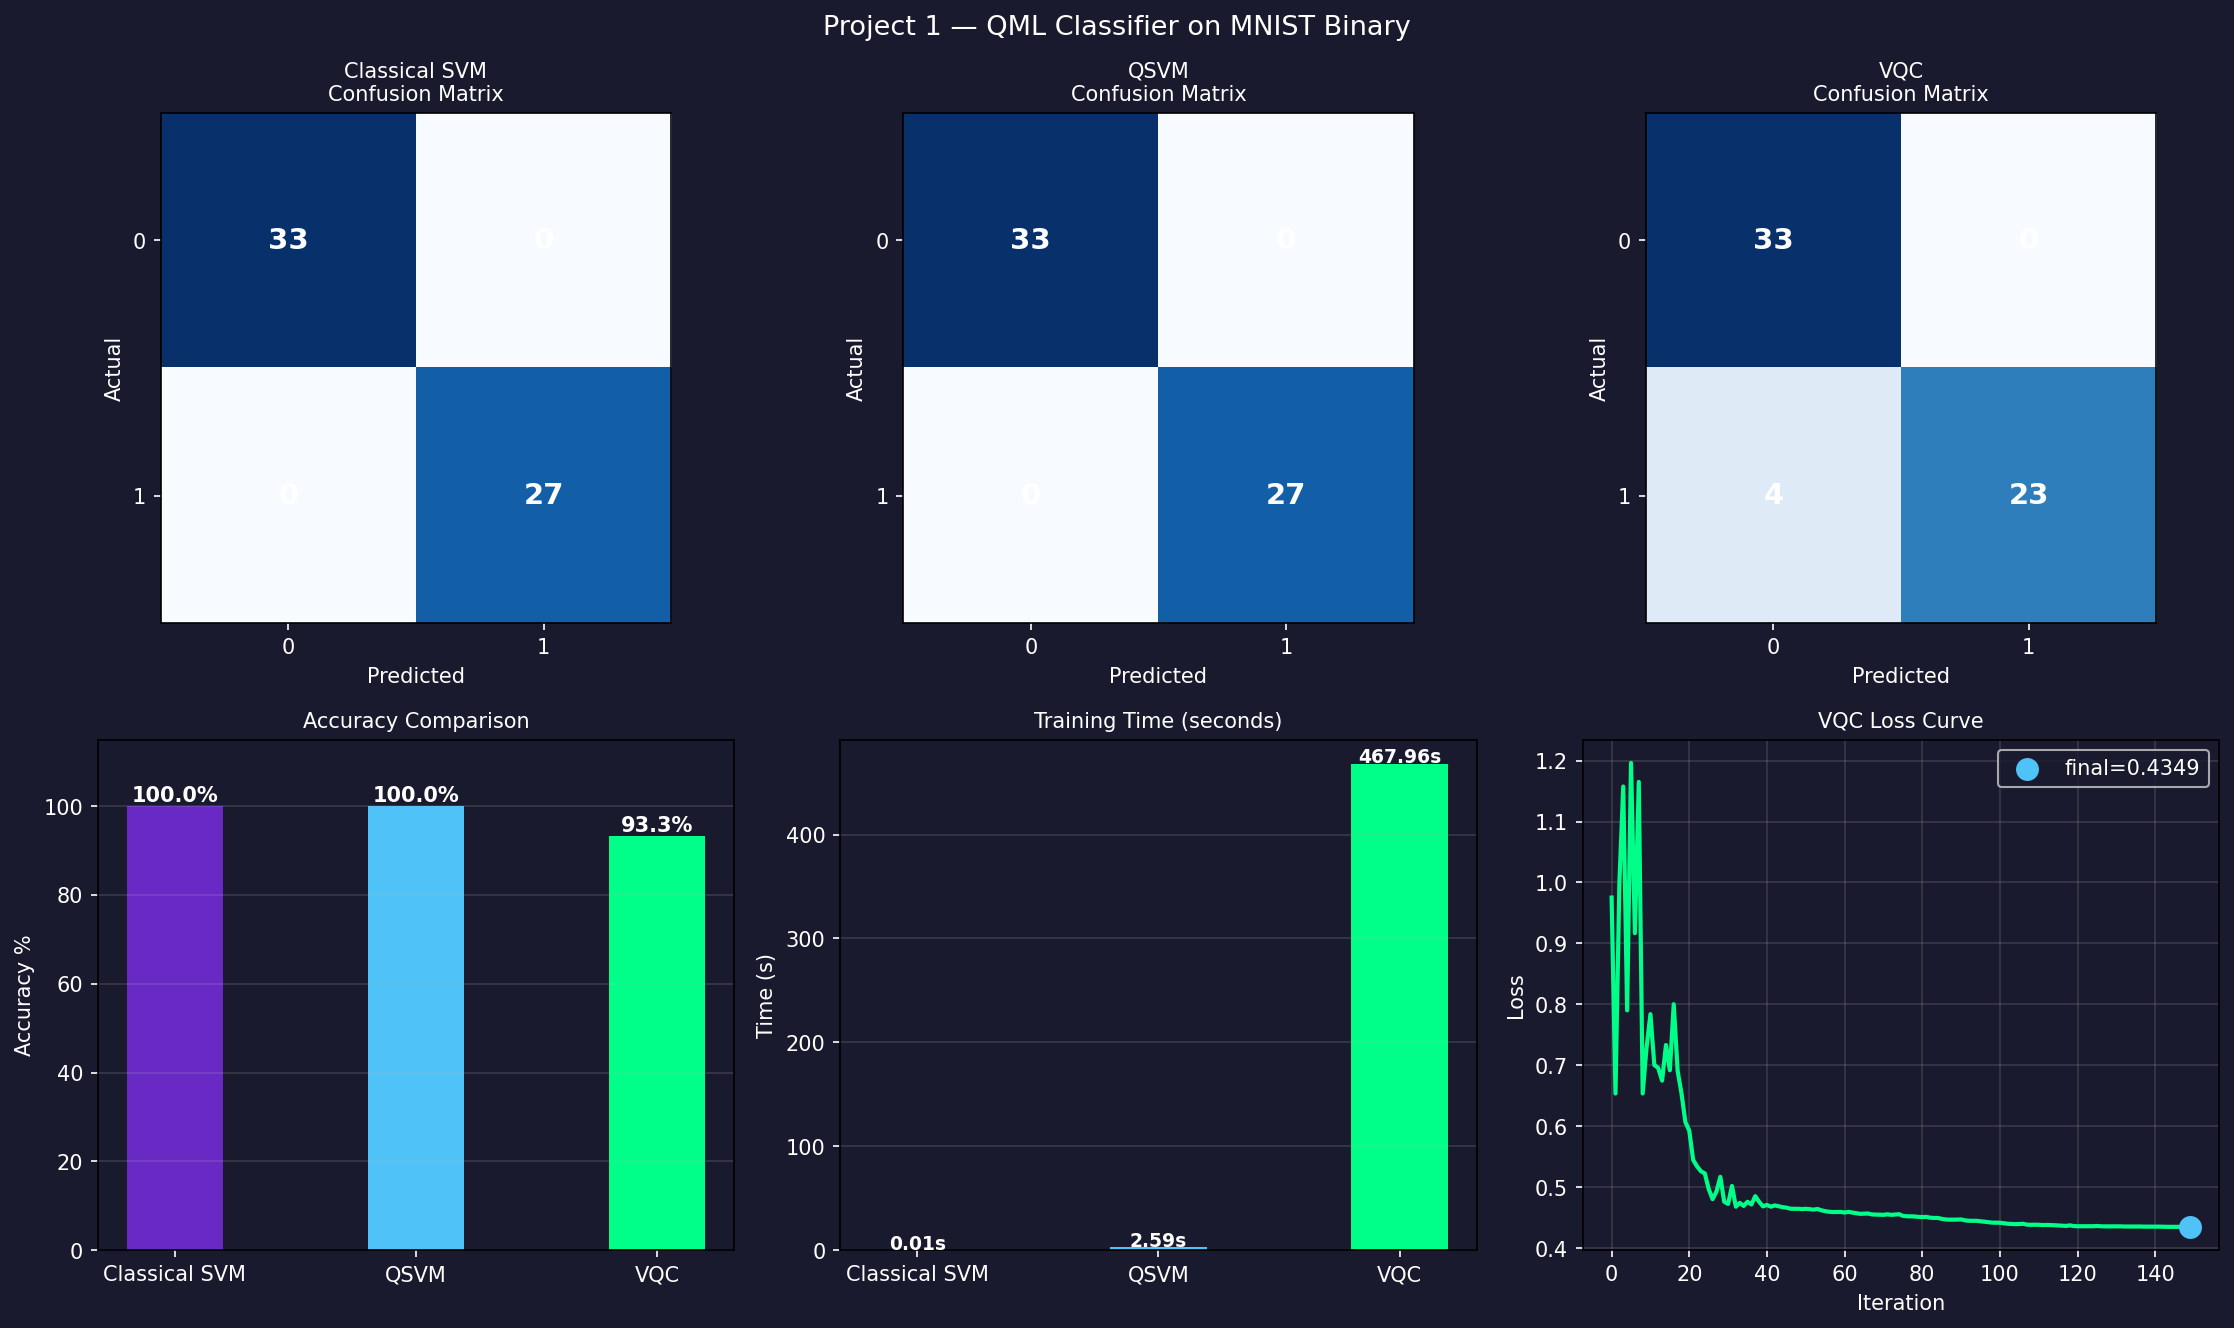

all plots saved!


In [7]:
# final comparison plots
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.patch.set_facecolor('#1a1a2e')

methods = ['Classical SVM', 'QSVM', 'VQC']
accuracies = [classical_accuracy*100,
              qsvm_accuracy*100,
              vqc_accuracy*100]
times = [classical_time, qsvm_time, vqc_time]
cms = [cm_classical, cm_qsvm, cm_vqc]
colors = ['#6929C4', '#4fc3f7', '#00ff88']

# row 1 - confusion matrices
for ax, cm, method, color in zip(
    axes[0], cms, methods, colors
):
    ax.set_facecolor('#1a1a2e')
    im = ax.imshow(cm, cmap='Blues')
    ax.set_title(f"{method}\nConfusion Matrix",
                 color='white', fontsize=10)
    ax.set_xlabel("Predicted", color='white')
    ax.set_ylabel("Actual", color='white')
    ax.tick_params(colors='white')
    ax.set_xticks([0,1])
    ax.set_yticks([0,1])
    ax.set_xticklabels(['0','1'])
    ax.set_yticklabels(['0','1'])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i][j]),
                    ha='center', va='center',
                    color='white',
                    fontweight='bold',
                    fontsize=14)

# row 2 - accuracy + time comparison
ax4 = axes[1][0]
ax4.set_facecolor('#1a1a2e')
bars = ax4.bar(methods, accuracies,
               color=colors, width=0.4)
ax4.set_title("Accuracy Comparison",
              color='white', fontsize=10)
ax4.set_ylabel("Accuracy %", color='white')
ax4.set_ylim(0, 115)
ax4.tick_params(colors='white')
ax4.grid(alpha=0.2, axis='y')
for bar, acc in zip(bars, accuracies):
    ax4.text(bar.get_x()+bar.get_width()/2,
             acc+1, f'{acc:.1f}%',
             ha='center', color='white',
             fontweight='bold', fontsize=10)

# training time
ax5 = axes[1][1]
ax5.set_facecolor('#1a1a2e')
bars2 = ax5.bar(methods,
                [t for t in times],
                color=colors, width=0.4)
ax5.set_title("Training Time (seconds)",
              color='white', fontsize=10)
ax5.set_ylabel("Time (s)", color='white')
ax5.tick_params(colors='white')
ax5.grid(alpha=0.2, axis='y')
for bar, t in zip(bars2, times):
    ax5.text(bar.get_x()+bar.get_width()/2,
             t+1, f'{t:.2f}s',
             ha='center', color='white',
             fontweight='bold', fontsize=9)

# VQC loss curve
ax6 = axes[1][2]
ax6.set_facecolor('#1a1a2e')
ax6.plot(loss_history, color='#00ff88',
         linewidth=2)
ax6.set_title("VQC Loss Curve",
              color='white', fontsize=10)
ax6.set_xlabel("Iteration", color='white')
ax6.set_ylabel("Loss", color='white')
ax6.tick_params(colors='white')
ax6.grid(alpha=0.2)
ax6.scatter(len(loss_history)-1,
            loss_history[-1],
            color='#4fc3f7', s=100, zorder=5,
            label=f'final={loss_history[-1]:.4f}')
ax6.legend(facecolor='#1a1a2e',
           labelcolor='white')

plt.suptitle(
    "Project 1 — QML Classifier on MNIST Binary",
    color='white', fontsize=13
)
plt.tight_layout()

save_path = "../results/qml_comparison.png"
plt.savefig(save_path, facecolor='#1a1a2e',
            bbox_inches='tight', dpi=150)
plt.close()
display(Image(filename=save_path))
print("all plots saved!")

## Project 1 — Final Results

| Method | Accuracy | Correct | Time |
|--------|----------|---------|------|
| Classical SVM | 100.00% | 60/60 | 0.013s |
| QSVM | 100.00% | 60/60 | 2.585s |
| VQC | 93.33% | 56/60 | 467.96s |

## Key Takeaways:
- QSVM matched classical SVM on MNIST (100%)!
- VQC achieved 93.33% — much better than Iris (60%)
- More complex dataset → quantum methods improve
- VQC needs more iterations for full convergence
- Classical SVM fastest — quantum has overhead
- QSVM sweet spot — quantum kernel, classical speed
- ZZFeatureMap captures feature interactions well

## Confusion Matrix Analysis:
- Classical SVM: 0 errors — perfect baseline
- QSVM: 0 errors — quantum kernel matched classical!
- VQC: 4 errors on digit 1 — still learning